In [52]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint

from langchain_core.messages import RemoveMessage

In [53]:
load_dotenv()

True

In [54]:
llm=HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    task="text-generation"
)

model=ChatHuggingFace(llm=llm)

In [55]:
def chat(state:MessagesState):
    response=model.invoke(state['messages'])
    return {"messages":[response]}

def delete_old_msg(state:MessagesState):
    msgs=state['messages']

    if len(msgs)>10:
        to_remove=msgs[:6]
        return {'messages':[RemoveMessage(id=m.id)for m in to_remove]}
    
    return{}

# def delete_old_msg(state: MessagesState):
#     msgs = state["messages"]

#     if len(msgs) > 10:
#         to_remove = msgs[:6]

#         return {
#             "messages": [RemoveMessage(id=m.id) for m in to_remove]
#         }

#     return {}

In [56]:
builder = StateGraph(MessagesState)

builder.add_node("MODEL", chat)
builder.add_node("Message Delete", delete_old_msg)

builder.add_edge(START, "MODEL")
builder.add_edge("MODEL","Message Delete")

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

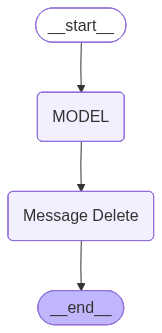

In [57]:
graph

In [58]:
config = {"configurable": {"thread_id": "t1"}}

In [59]:
# Run multiple turns

In [60]:
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Amrit"}]}, config)

{'messages': [HumanMessage(content="Hi, I'm Amrit", additional_kwargs={}, response_metadata={}, id='5120f8e2-6208-484d-bf71-3b08183d0816'),
  AIMessage(content='Hello Amrit! 👋 Great to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 72, 'total_tokens': 137}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_46358675aa6b1ba4d98d', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e7e02-4990-7673-9e48-1f4a0dc59b4c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 65, 'total_tokens': 137})]}

In [61]:

graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)

{'messages': [HumanMessage(content="Hi, I'm Amrit", additional_kwargs={}, response_metadata={}, id='5120f8e2-6208-484d-bf71-3b08183d0816'),
  AIMessage(content='Hello Amrit! 👋 Great to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 72, 'total_tokens': 137}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_46358675aa6b1ba4d98d', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e7e02-4990-7673-9e48-1f4a0dc59b4c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 65, 'total_tokens': 137}),
  HumanMessage(content='Tell me about LangGraph', additional_kwargs={}, response_metadata={}, id='40d61dee-e4c5-4644-ba9b-ab4d65fc74e8'),
  AIMessage(content='## What is **LangGraph**?  \n\n**LangGraph** is an open‑source Python library (maintained by the LangChain community) that makes it easy to build **state‑driven, multi‑step workflows** on top 

In [62]:

graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)

{'messages': [HumanMessage(content="Hi, I'm Amrit", additional_kwargs={}, response_metadata={}, id='5120f8e2-6208-484d-bf71-3b08183d0816'),
  AIMessage(content='Hello Amrit! 👋 Great to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 72, 'total_tokens': 137}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_46358675aa6b1ba4d98d', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e7e02-4990-7673-9e48-1f4a0dc59b4c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 65, 'total_tokens': 137}),
  HumanMessage(content='Tell me about LangGraph', additional_kwargs={}, response_metadata={}, id='40d61dee-e4c5-4644-ba9b-ab4d65fc74e8'),
  AIMessage(content='## What is **LangGraph**?  \n\n**LangGraph** is an open‑source Python library (maintained by the LangChain community) that makes it easy to build **state‑driven, multi‑step workflows** on top 

In [63]:

graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)

{'messages': [HumanMessage(content="Hi, I'm Amrit", additional_kwargs={}, response_metadata={}, id='5120f8e2-6208-484d-bf71-3b08183d0816'),
  AIMessage(content='Hello Amrit! 👋 Great to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 72, 'total_tokens': 137}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_46358675aa6b1ba4d98d', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e7e02-4990-7673-9e48-1f4a0dc59b4c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 65, 'total_tokens': 137}),
  HumanMessage(content='Tell me about LangGraph', additional_kwargs={}, response_metadata={}, id='40d61dee-e4c5-4644-ba9b-ab4d65fc74e8'),
  AIMessage(content='## What is **LangGraph**?  \n\n**LangGraph** is an open‑source Python library (maintained by the LangChain community) that makes it easy to build **state‑driven, multi‑step workflows** on top 

In [64]:

graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)

{'messages': [HumanMessage(content="Hi, I'm Amrit", additional_kwargs={}, response_metadata={}, id='5120f8e2-6208-484d-bf71-3b08183d0816'),
  AIMessage(content='Hello Amrit! 👋 Great to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 72, 'total_tokens': 137}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_46358675aa6b1ba4d98d', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e7e02-4990-7673-9e48-1f4a0dc59b4c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 65, 'total_tokens': 137}),
  HumanMessage(content='Tell me about LangGraph', additional_kwargs={}, response_metadata={}, id='40d61dee-e4c5-4644-ba9b-ab4d65fc74e8'),
  AIMessage(content='## What is **LangGraph**?  \n\n**LangGraph** is an open‑source Python library (maintained by the LangChain community) that makes it easy to build **state‑driven, multi‑step workflows** on top 

In [65]:
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='15ce0112-93ad-41ae-a05f-97da8cfb007d'),
  AIMessage(content='## LangChain – The “Glue” for LLM‑Powered Applications  \n\n### TL;DR\n**LangChain** is an open‑source Python (and JavaScript/TypeScript) library that helps developers **build, orchestrate, and manage** applications that use large language models (LLMs).  \nIt provides **building blocks** (prompts, chains, agents, memory, retrievers, tools, callbacks, etc.) that you can connect together—much like LEGO bricks—to create anything from a simple Q&A bot to a multi‑step autonomous agent.\n\n---\n\n## 1. Why LangChain Exists  \n\nLLM APIs (OpenAI, Anthropic, Cohere, Gemini, etc.) are **stateless**: you send a prompt, get a completion, and that’s it. Real‑world AI products, however, often need:\n\n| Need | What you have to implement yourself | How LangChain helps |\n|------|--------------------------------------|-------------------

In [66]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='15ce0112-93ad-41ae-a05f-97da8cfb007d'),
  AIMessage(content='## LangChain – The “Glue” for LLM‑Powered Applications  \n\n### TL;DR\n**LangChain** is an open‑source Python (and JavaScript/TypeScript) library that helps developers **build, orchestrate, and manage** applications that use large language models (LLMs).  \nIt provides **building blocks** (prompts, chains, agents, memory, retrievers, tools, callbacks, etc.) that you can connect together—much like LEGO bricks—to create anything from a simple Q&A bot to a multi‑step autonomous agent.\n\n---\n\n## 1. Why LangChain Exists  \n\nLLM APIs (OpenAI, Anthropic, Cohere, Gemini, etc.) are **stateless**: you send a prompt, get a completion, and that’s it. Real‑world AI products, however, often need:\n\n| Need | What you have to implement yourself | How LangChain helps |\n|------|--------------------------------------|-------------------

In [67]:
snap = graph.get_state(config)

print("Stored messages after cleanup:", len(snap.values["messages"]))

for msg in snap.values["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

Stored messages after cleanup: 8
HumanMessage: What is Langchain
AIMessage: ## LangChain – The “Glue” for LLM‑Powered Applications  

### TL;DR
**LangChain** is an open‑source Python (and JavaScript/TypeScript) library that helps developers **build, orchestrate, and manage** applications that use large language models (LLMs).  
It provides **building blocks** (prompts, chains, agents, memory, retrievers, tools, callbacks, etc.) that you can connect together—much like LEGO bricks—to create anything from a simple Q&A bot to a multi‑step autonomous agent.

---

## 1. Why LangChain Exists  

LLM APIs (OpenAI, Anthropic, Cohere, Gemini, etc.) are **stateless**: you send a prompt, get a completion, and that’s it. Real‑world AI products, however, often need:

| Need | What you have to implement yourself | How LangChain helps |
|------|--------------------------------------|----------------------|
| **Prompt templating** | String interpolation, few‑shot examples, variable substitution | `Promp